# Simple Grid World: Approximation

## Installation and Setup

You need:
* Gymnasium (see [Installation Instructions](../common/Setup_Gymnasium.ipynb))
* Patched `gym-classics-1.0.0+internal.rev1` or later (see [Installation instructions](../common/Setup_patched_gym_classics.ipynb))

In [217]:
import numpy as np
np.set_printoptions(precision=2)

In [218]:
import gymnasium as gym
import gym_classics
gym_classics.register('gymnasium')

/home/mhahsler/github/Introduction_to_Reinforcement_Learning/common/gym-classics/gym_classics/__init__.py:83: UserWarning: gym-classics environments were already registered for gymnasium; additional calls to `register()` are ignored.
  warnings.warn("gym-classics environments were already registered for {}; "


## Define an Empty 5x5 Grid 

A maze without walls. The step cost is 1. The start is (0,0) and
the goal (+100 reward) is (4,4).
This is the ideal problem for a linear approximation of the Q-function
using the x/y location as state features.

In [219]:
from gym_classics.envs.abstract.gridworld import Gridworld

class EmptyGridworld(Gridworld):
    layout = """
|    G|
|     |
|     |
|     |
|S    |
"""

    def __init__(self):
        super().__init__(self.layout)

    def _reward(self, state, action, next_state):
        if state in self._goals:
            return 0.0
        return {(4, 4): 100.0}.get(next_state, -1)

    def _done(self, state, action, next_state):
        return next_state in self._goals   

gym.register('EmptyGridworld-v1', entry_point=EmptyGridworld)

/home/mhahsler/github/Introduction_to_Reinforcement_Learning/.venv/lib/python3.12/site-packages/gymnasium/envs/registration.py:636: UserWarning: WARN: Overriding environment EmptyGridworld-v1 already in registry.
  logger.warn(f"Overriding environment {new_spec.id} already in registry.")


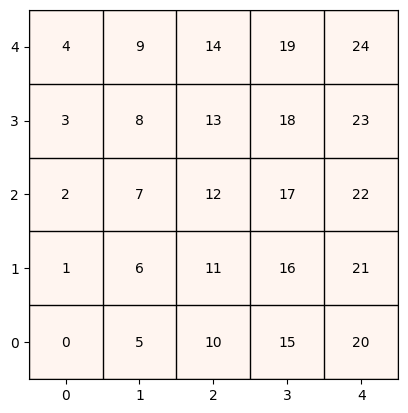

In [220]:
gym_env = gym.make('EmptyGridworld-v1')
env = gym_env.unwrapped

env.image()

In [221]:
from gym_classics.algorithms.MC import sample_episode

sample_episode(env, max_len=10000)

[(0, 0, -1, 1),
 (1, 0, -1, 2),
 (2, 2, -1, 1),
 (1, 3, -1, 1),
 (1, 1, -1, 6),
 (6, 0, -1, 7),
 (7, 3, -1, 2),
 (2, 1, -1, 7),
 (7, 0, -1, 8),
 (8, 0, -1, 9),
 (9, 2, -1, 8),
 (8, 0, -1, 9),
 (9, 1, -1, 14),
 (14, 2, -1, 13),
 (13, 3, -1, 8),
 (8, 0, -1, 9),
 (9, 1, -1, 14),
 (14, 1, -1, 19),
 (19, 0, -1, 19),
 (19, 1, 100.0, 24)]

## State Features

We use here simply the x and y-coordinates as the state feature vector $\mathbf{x}(s)$. We also add an intercept (a 1) to the beginning so we end up with a 3-dimensional state feature.

`[intercept (always 1), x, y]`

In [222]:
coordinates = [env.decode(s) for s in range(env.observation_space.n)]
state_features = [np.concatenate([np.array([1]), np.array(coord)]) for coord in coordinates]

state_features

[array([1, 0, 0]),
 array([1, 0, 1]),
 array([1, 0, 2]),
 array([1, 0, 3]),
 array([1, 0, 4]),
 array([1, 1, 0]),
 array([1, 1, 1]),
 array([1, 1, 2]),
 array([1, 1, 3]),
 array([1, 1, 4]),
 array([1, 2, 0]),
 array([1, 2, 1]),
 array([1, 2, 2]),
 array([1, 2, 3]),
 array([1, 2, 4]),
 array([1, 3, 0]),
 array([1, 3, 1]),
 array([1, 3, 2]),
 array([1, 3, 3]),
 array([1, 3, 4]),
 array([1, 4, 0]),
 array([1, 4, 1]),
 array([1, 4, 2]),
 array([1, 4, 3]),
 array([1, 4, 4])]

Linear approximation of the value function just mean we calculate a weighted sum of the state feature components:

$\hat{v}(s,\mathbf{w}) = \mathbf{w}^\top \mathbf{x}(s)$, 

where $\mathbf{w}$ is the weight vector we want to learn.

In [223]:
def v_hat(s, w):
    x_s = state_features[s]
    return np.dot(w, x_s)

For example, I manually define here a weight vector.

In [224]:
w = np.array([1, 5, 10])

This means the smallest value at $(0,0)$ is the intercept of 1 and the value function increases by 5 for every step in the x direction and ny
10 in the y direction.

In [225]:

print (f" v_hat((0,0), w) = {v_hat(env.encode((0,0)), w)}")
print (f" v_hat((4,4), w) = {v_hat(env.encode((4,4)), w)}")

 v_hat((0,0), w) = 1
 v_hat((4,4), w) = 61


Here is the value function for the weights.

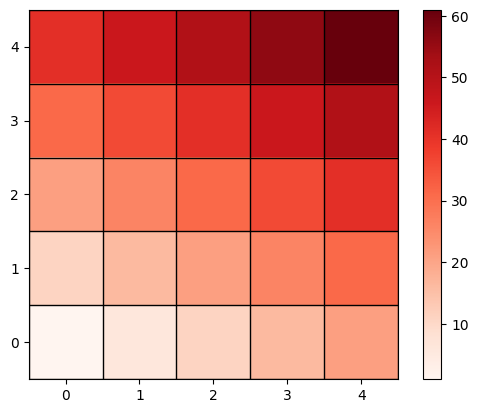

In [226]:
V = np.array([v_hat(s, w) for s in range(env.observation_space.n)])
env.image(V)

# Learning w for a given Policy 


We want to minimize the mean square value error: $\overline{VE} = \sum_{s\in \mathcal{S}} \mu(s) [v_\pi - \hat{v}(s, \mathbf{w})]^2$

This leads to:

* SGD update: $\mathbf{w}_{t+1} = \mathbf{w}_t + \alpha (U_t - \hat{v}(S_t, \mathbf{w}_t)) \mathbf{x}(S_t)$
* Gradient: $\nabla \hat{v}(s, \mathbf{w}) = \mathbf{x}(s)$


We could use the gradient Monte Carlo algorithm, but we show here the
Semi-Gradient TD(0) Algorithm with Linear Function Approximation.



![Semi-Gradient TD(0)](https://raw.githubusercontent.com/mhahsler/Introduction_to_Reinforcement_Learning/refs/heads/main/figures/RL-Intro_Alg_Semi_gradient_TD0.png)

In [227]:
def semi_gradient_TD0_estimation(env, policy, n, alpha, gamma, max_episode_length=100, verbose = True):
    assert alpha > 0 and alpha <= 1, "Alpha must be in (0,1]"
    assert gamma >= 0 and gamma <= 1, "Gamma must be in [0,1]"
    assert n > 0, "Number of episodes must be positive"
    assert max_episode_length > 0, "Max episode length must be positive"
    
    w = np.zeros(3)  # Initialize weights (intercept + x and y)

    for episode in range(n):
        state, _ = env.reset()
        done = False

        i = 0
        while not done and i < max_episode_length:
            action = policy[state]  # follow policy
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            
            # Semi-gradient TD(0) update
            # Note: v_hat(terminal, w) needs to be 0
            if terminated:
                w += alpha * (reward - v_hat(state, w)) * state_features[state]    
            else: 
                w += alpha * (reward + gamma * v_hat(next_state, w) - v_hat(state, w)) * state_features[state]
             
            if verbose:
                print (f"Episode {episode+1}, Step {i+1}: S={state}, A={action}, R={reward}, S'={next_state}, w={w}")

            state = next_state
            i += 1

    return w

I will manually create a policy to evaluate.

In [228]:
pol = np.full(env.observation_space.n, env.encode_action('up'))
pol[[4, 9, 14, 19]] = env.encode_action('right')
pol

array([0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0])

In [229]:
w = semi_gradient_TD0_estimation(env, pol, n=1000, alpha=0.01, gamma=1, verbose=False)
w

array([93.,  1.,  1.])

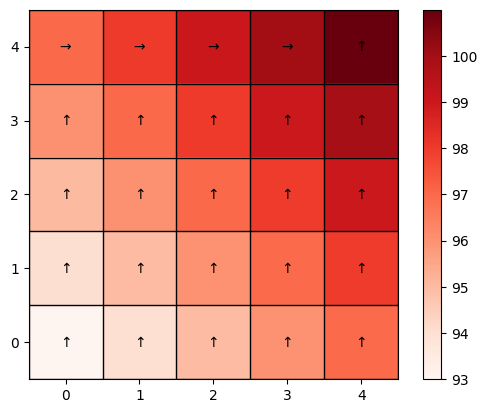

In [230]:
V = np.array([v_hat(s, w) for s in range(env.observation_space.n)])
env.image(V, policy=pol)

In [231]:
V.reshape(5,5)[::-1]

array([[ 97.,  98.,  99., 100., 101.],
       [ 96.,  97.,  98.,  99., 100.],
       [ 95.,  96.,  97.,  98.,  99.],
       [ 94.,  95.,  96.,  97.,  98.],
       [ 93.,  94.,  95.,  96.,  97.]])

# Semi-Gradient Sarsa

![Semi-Gradient Sarsa](https://raw.githubusercontent.com/mhahsler/Introduction_to_Reinforcement_Learning/refs/heads/main/figures/RL-Intro_Alg_Semi_gradient_SARSA.png)

To construct a linear state-action approximation function is a little more tricky. [Geramifard et al. (2013)](https://doi.org/10.1561/2200000042) suggest to use a state feature vectors to construct the complete state-action feature vector. It uses one shared intercept and then for each action a state feature component.
In our case we get a $w$ vectors of length 1 intercept + 4 actions $\times$ 2 coordinate values = 9. Here is the layout for the weight vector $\mathbf{w}$:

`[intercept, x_action0, y_action0, x_action1, y_action1, x_action2, y_action2, x_action3, y_action3]`

Only the intercept and the weights belonging to the action are used.

In [232]:
# choose intercept at 0 and the action-specific weights so we end up with 3 active weights.
def active_weights(a):
    return [0, a * 2 + 1, a * 2 + 2]

active_weights(1)

[0, 3, 4]

In [233]:
def q_hat(s, a, w): 
    w_action = w[active_weights(a)]
    return np.dot(w_action, state_features[s])

In [234]:
w = np.array([1,2,2,3,3,4,4,5,5])

# state 7 is (2,1): for action 2 this should be 1 (intercept) + 2*4+1*4 = 13
q_hat(7, 2, w)

np.int64(13)

In [235]:
def semi_gradient_Sarsa(env, n, epsilon, alpha, gamma, w = None, max_episode_length=100, verbose = True):
    assert alpha > 0 and alpha <= 1, "Alpha must be in (0,1]"
    assert gamma >= 0 and gamma <= 1, "Gamma must be in [0,1]"
    assert epsilon >=0 and epsilon <=1, "Epsilon must be in [0,1]"
    assert n > 0, "Number of episodes must be positive"
    assert max_episode_length > 0, "Max episode length must be positive"

    if w is None:
        w = np.zeros(9)  # Initialize weights (intercept + action weights)

    # helper used later
    def epsilon_greedy_action(state, epsilon):
        if np.random.rand() < epsilon:
            return env.action_space.sample()
        else:
            q_values = [q_hat(state, a, w) for a in range(env.action_space.n)]
            return np.argmax(q_values)
    
    for episode in range(n):
        state, _ = env.reset()
        action = epsilon_greedy_action(state, epsilon)
        done = False

        i = 0
        while not done and i < max_episode_length:
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            
            if terminated:
                next_action = None
                w[active_weights(action)] += alpha * (reward - q_hat(state, action, w)) * state_features[state]
                
            else:
                next_action = epsilon_greedy_action(next_state, epsilon)
                w[active_weights(action)] += alpha * (reward + gamma * q_hat(next_state, next_action, w) - q_hat(state, action, w)) * state_features[state]
             
            if verbose:
                print (f"Episode {episode+1}, Step {i+1}: S={state}, A={action}, R={reward}, S'={next_state}, w={w}")

            state = next_state
            action = next_action
            i += 1

    return w  
    

### Tests With Different Learning Rates 

In [236]:
# helper to visualize the learned policy and value function 
def plot_w(w, title=None):
    Q = np.array([[q_hat(s, a, w) for a in range(env.action_space.n)] for s in range(env.observation_space.n)])
    V = np.max(Q, axis=1)
    pol = greedy_policy(env, V)
    env.image(V, policy=pol, title=title)
    
    return Q, V, pol

Convergence is an issue with semi-gradient methods and depends on the choice of the learning rate.

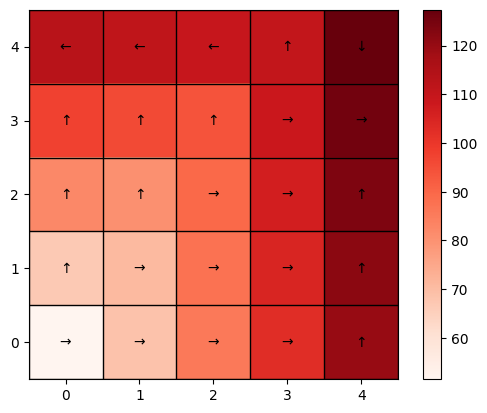

(array([[ 51.52,  51.52,  51.52,  51.52],
        [ 53.43,  66.92,  58.54,  58.79],
        [ 55.33,  82.31,  65.56,  66.06],
        [ 57.24,  97.71,  72.58,  73.33],
        [ 59.15, 113.1 ,  79.61,  80.6 ],
        [ 68.57,  49.75,  60.67,  59.45],
        [ 70.48,  65.14,  67.69,  66.72],
        [ 72.39,  80.54,  74.71,  73.99],
        [ 74.29,  95.94,  81.74,  81.26],
        [ 76.2 , 111.33,  88.76,  88.53],
        [ 85.62,  47.98,  69.82,  67.39],
        [ 87.53,  63.37,  76.84,  74.66],
        [ 89.44,  78.77,  83.87,  81.93],
        [ 91.34,  94.16,  90.89,  89.2 ],
        [ 93.25, 109.56,  97.91,  96.47],
        [102.67,  46.2 ,  78.97,  75.32],
        [104.58,  61.6 ,  86.  ,  82.59],
        [106.49,  77.  ,  93.02,  89.86],
        [108.39,  92.39, 100.04,  97.13],
        [110.3 , 107.79, 107.06, 104.4 ],
        [119.72,  44.43,  88.13,  83.26],
        [121.63,  59.83,  95.15,  90.53],
        [123.54,  75.22, 102.17,  97.8 ],
        [125.45,  90.62, 109.19, 1

In [237]:
w = semi_gradient_Sarsa(env, n=100, epsilon=0.1, alpha=0.01, gamma=1, verbose=False)
plot_w(w)

Learning most likely did not converge! We need to reduce the learning rate.

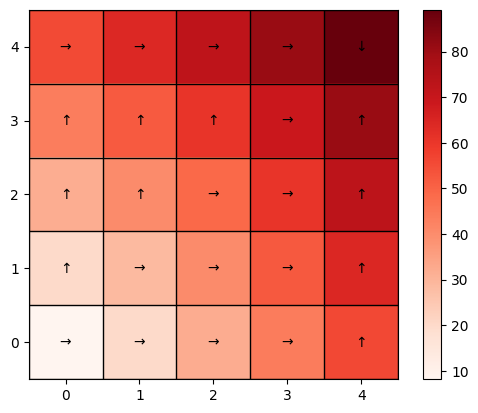

array([ 8.13, 19.95, 31.78, 43.6 , 55.42, 20.07, 28.4 , 40.22, 52.04,
       63.87, 32.01, 40.33, 48.66, 60.49, 72.31, 43.95, 52.27, 60.58,
       68.93, 80.75, 55.89, 64.21, 72.52, 80.84, 89.2 ])

In [238]:
w = semi_gradient_Sarsa(env, n=100, epsilon=0.1, alpha=0.001, gamma=1, verbose=False)
Q, V, pol = plot_w(w)
V

The policy looks much better. The policy points towards the shortest path to the goal. 

Let's compare the learned value function with it with the optimal value function. Since we have model access, we can calculate it using value iteration.

In [239]:
from gym_classics.algorithms.DP import value_iteration
V_true = value_iteration(env, discount = 1)
V_true 

array([ 93.,  94.,  95.,  96.,  97.,  94.,  95.,  96.,  97.,  98.,  95.,
        96.,  97.,  98.,  99.,  96.,  97.,  98.,  99., 100.,  97.,  98.,
        99., 100., 100.])

In [240]:
# mean squared value error
def MSVE(V, V_true):
    return np.sqrt(np.mean((V - V_true)**2))

In [241]:
msve = MSVE(V, V_true)
msve_sqrt = np.sqrt(msve)

print(f"MSVE: {msve}, sqrt(MSVE): {msve_sqrt}")

MSVE: 49.104605664413285, sqrt(MSVE): 7.007467849688165


### Experiment With Learning

In [242]:
w = np.zeros(9)
w_list = []

for _ in range(1000):
    w = semi_gradient_Sarsa(env, n=1, epsilon=0.1, alpha=0.001, gamma=1, w = w, verbose=False)
    w_list.append(w.copy())

display(w_list)

[array([ 0.08, -0.01, -0.02,  0.3 ,  0.39, -0.  , -0.01, -0.  , -0.01]),
 array([-0.02, -0.01, -0.02, -0.08,  0.32, -0.01, -0.01, -0.  , -0.01]),
 array([ 0.02,  0.37,  0.28, -0.22,  0.23, -0.03, -0.02, -0.03, -0.02]),
 array([-0.08,  0.24, -0.09, -0.23,  0.22, -0.03, -0.02, -0.03, -0.02]),
 array([ 0.01,  0.21, -0.13,  0.07,  0.61, -0.03, -0.02, -0.03, -0.02]),
 array([ 0.03,  0.59,  0.16, -0.19,  0.45, -0.03, -0.03, -0.02, -0.02]),
 array([ 0.09,  0.5 ,  0.01,  0.1 ,  0.83, -0.03, -0.02, -0.02, -0.02]),
 array([ 0.15,  0.87,  0.3 , -0.06,  0.71, -0.02, -0.01, -0.01, -0.01]),
 array([ 0.19,  0.73,  0.1 ,  0.23,  1.09, -0.02, -0.01, -0.01, -0.  ]),
 array([ 0.28,  1.12,  0.39,  0.19,  1.06, -0.02, -0.01, -0.01, -0.  ]),
 array([ 0.36,  1.1 ,  0.37,  0.47,  1.44, -0.02, -0.01, -0.01, -0.  ]),
 array([ 0.44,  1.48,  0.65,  0.39,  1.37, -0.02, -0.01,  0.01,  0.01]),
 array([ 0.52,  1.43,  0.58,  0.67,  1.74, -0.02, -0.01,  0.01,  0.01]),
 array([ 0.59,  1.8 ,  0.86,  0.58,  1.67, -0.02, -

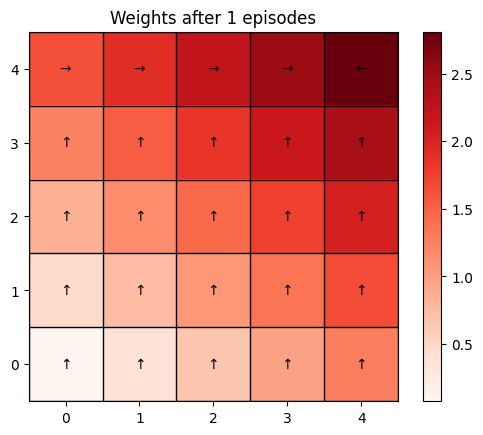

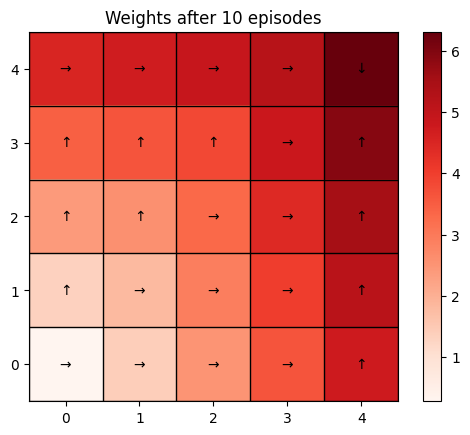

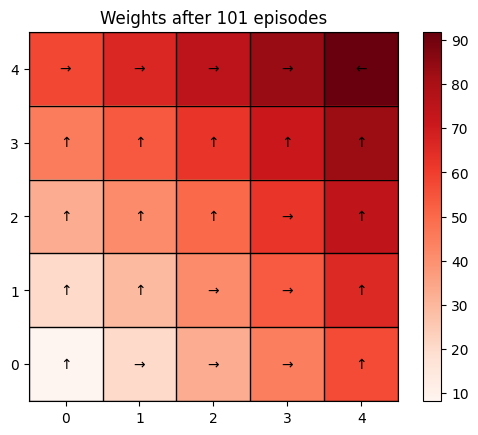

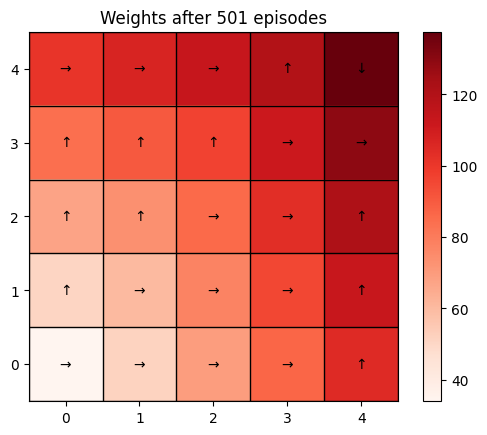

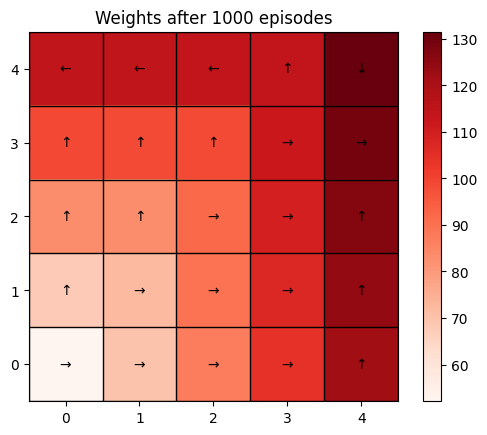

In [243]:
for i in [0,9, 100, 500, 999]:
    Q, V, pol = plot_w(w_list[i], title=f"Weights after {i+1} episodes")    

Look at MSVE over episodes.

In [244]:
def MSVE_w(w):
    Q = np.array([[q_hat(s, a, w) for a in range(env.action_space.n)] for s in range(env.observation_space.n)])
    V = np.max(Q, axis=1)
    return MSVE(V, V_true)  

msve = [MSVE_w(w) for w in w_list]

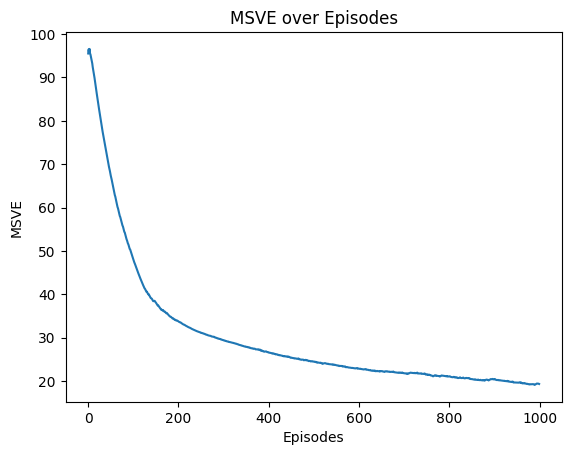

In [245]:
import matplotlib.pyplot as plt 

# plot MSVE over episodes
plt.plot(msve)
plt.xlabel('Episodes')
plt.ylabel('MSVE')
plt.title('MSVE over Episodes')
plt.show()


# Change Learning Rate Over Time

For gradient descent methods,
it is a good idea to reduce the learning rate over time.

In [246]:
w = np.zeros(9)
w_list = []

def alpha_schedule(episode, alpha_0=0.001, k=0.01):
    return alpha_0 / (1 + k * episode)

for i in range(10000):
    w = semi_gradient_Sarsa(env, n=1, epsilon=0.1, alpha=alpha_schedule(i), gamma=1, w = w, verbose=False)
    w_list.append(w.copy())

display(w_list)

[array([ 0.04, -0.02, -0.03,  0.28,  0.37, -0.02, -0.03, -0.02, -0.03]),
 array([-0.05, -0.02, -0.03, -0.08,  0.27, -0.02, -0.03, -0.03, -0.03]),
 array([-0.01,  0.35,  0.26, -0.23,  0.18, -0.04, -0.04, -0.05, -0.04]),
 array([-0.11,  0.24, -0.09, -0.23,  0.15, -0.04, -0.04, -0.05, -0.04]),
 array([-0.04,  0.18, -0.17,  0.05,  0.53, -0.04, -0.04, -0.06, -0.05]),
 array([ 0.01,  0.55,  0.11, -0.09,  0.45, -0.04, -0.04, -0.06, -0.05]),
 array([ 0.1 ,  0.55,  0.11,  0.18,  0.82, -0.04, -0.04, -0.06, -0.05]),
 array([ 0.15,  0.9 ,  0.37,  0.06,  0.72, -0.04, -0.04, -0.04, -0.03]),
 array([ 0.19,  0.76,  0.18,  0.32,  1.07, -0.04, -0.04, -0.03, -0.02]),
 array([ 0.26,  1.11,  0.45,  0.24,  1.01, -0.03, -0.03, -0.03, -0.02]),
 array([ 0.33,  1.03,  0.36,  0.5 ,  1.35, -0.01, -0.01, -0.02, -0.01]),
 array([ 4.01e-01,  1.38e+00,  6.11e-01,  4.46e-01,  1.31e+00,  6.37e-04,
         2.23e-03, -2.22e-02, -1.08e-02]),
 array([ 4.84e-01,  1.37e+00,  6.10e-01,  6.95e-01,  1.64e+00,  6.37e-04,
      

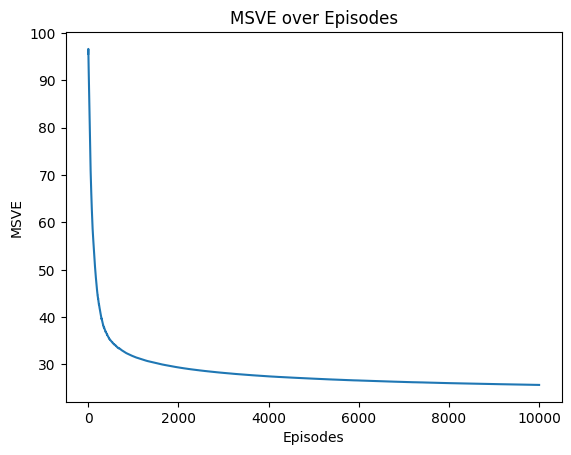

In [247]:
msve = [MSVE_w(w) for w in w_list]

plt.plot(msve)
plt.xlabel('Episodes')
plt.ylabel('MSVE')
plt.title('MSVE over Episodes')
plt.show()

Note: Play with `alpha_0` and `k` to see how instable learning is! 


&copy; 2025 [Michael Hahsler](http://michael.hahsler.net). 
This work is openly licensed under [Creative Commons Attribution-ShareAlike 4.0 International (CC BY-SA 4.0) License](https://creativecommons.org/licenses/by-sa/4.0/)

![CC BY-SA 4.0](https://licensebuttons.net/l/by-sa/3.0/88x31.png)